# Gradient Boosting

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd

In [3]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

In [4]:
df = pd.DataFrame()
df['X'] = X.reshape(100)
df['y'] = y

In [5]:
df

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


Text(0.5, 1.0, 'X vs Y')

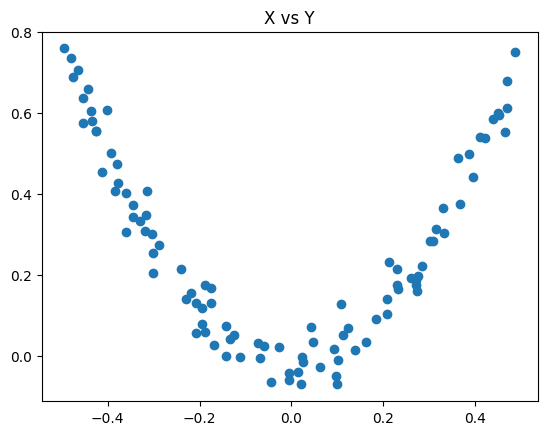

In [6]:
plt.scatter(df['X'], df['y'])
plt.title('X vs Y')

In [7]:
# Model 1 predict the only mean
df['pred1'] = df['y'].mean()
df

,X,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458
...,...,...,...
95,-0.006204,-0.040675,0.265458
96,0.022733,-0.002305,0.265458
97,-0.072459,0.032809,0.265458
98,-0.474581,0.689516,0.265458


In [8]:
df['res1'] = df['y'] - df['pred1']

plt.scatter(df['X'], df['y'])
plt.plot(df['X'], df['pred1'], color='red')

In [12]:
from sklearn.tree import DecisionTreeRegressor

In [13]:
tree1 = DecisionTreeRegressor(max_leaf_nodes=8)

In [15]:
tree1.fit(df['X'].values.reshape(100, 1), df['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

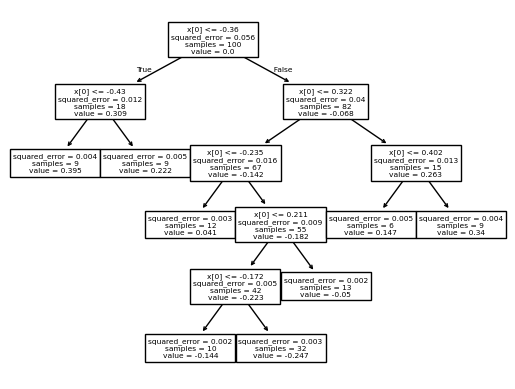

In [16]:
from sklearn.tree import plot_tree
plot_tree(tree1)
plt.show()

In [19]:
X_test = np.linspace(-0.5, 0.5, 500)

In [23]:
y_pred = 0.2654 + tree1.predict(X_test.reshape(500, 1))

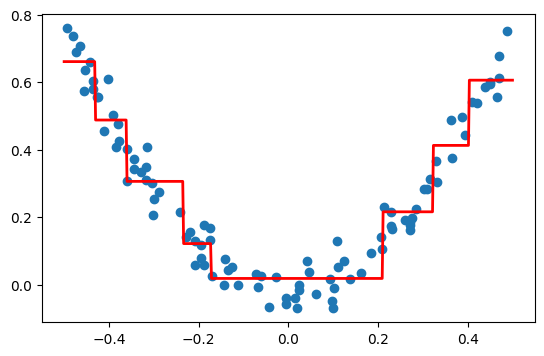

In [24]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2, color='red')
plt.scatter(df['X'], df['y'])

In [26]:
df['pred2'] = 0.2654 + tree1.predict(df['X'].values.reshape(100, 1))

In [27]:
df

,X,y,pred1,res1,pred2
0,-0.125460,0.051573,0.265458,-0.213885,0.018261
1,0.450714,0.594480,0.265458,0.329021,0.605826
2,0.231994,0.166052,0.265458,-0.099407,0.215726
3,0.098658,-0.070178,0.265458,-0.335636,0.018261
4,-0.343981,0.343986,0.265458,0.078528,0.305906
...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018261
96,0.022733,-0.002305,0.265458,-0.267763,0.018261
97,-0.072459,0.032809,0.265458,-0.232650,0.018261
98,-0.474581,0.689516,0.265458,0.424057,0.660854


In [28]:
df['res2'] = df['y'] - df['pred2']
df

,X,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.018261,0.033312
1,0.450714,0.594480,0.265458,0.329021,0.605826,-0.011346
2,0.231994,0.166052,0.265458,-0.099407,0.215726,-0.049674
3,0.098658,-0.070178,0.265458,-0.335636,0.018261,-0.088439
4,-0.343981,0.343986,0.265458,0.078528,0.305906,0.038080
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018261,-0.058936
96,0.022733,-0.002305,0.265458,-0.267763,0.018261,-0.020566
97,-0.072459,0.032809,0.265458,-0.232650,0.018261,0.014547
98,-0.474581,0.689516,0.265458,0.424057,0.660854,0.028662


In [29]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)

In [30]:
tree2.fit(df['X'].values.reshape(100, 1), df['res2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [31]:
y_pred = 0.2654 + sum(regressor.predict(X_test.reshape(-1, 1)) for regressor in [tree1, tree2])

Text(0.5, 1.0, 'X vs y')

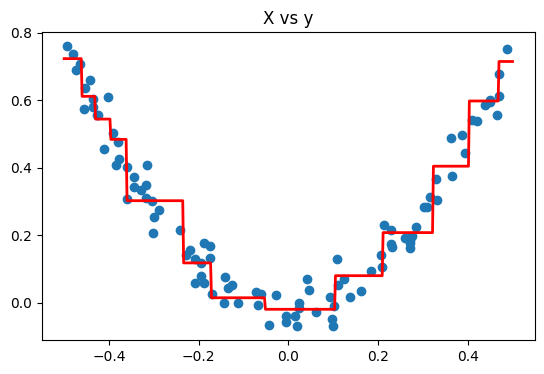

In [32]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])
plt.title('X vs y')

In [33]:
def gradient_boost(X,y,number,lr,count=1,regs=[],foo=None):

  if number == 0:
    return 
  else:
    # do gradient boosting

    if count > 1:
      y = y - regs[-1].predict(X)
    else:
      foo = y

    tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree_reg.fit(X, y)

    regs.append(tree_reg)

    x1 = np.linspace(-0.5, 0.5, 500)
    y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

    print(number)
    plt.figure()
    plt.plot(x1, y_pred, linewidth=2)
    plt.plot(X[:, 0], foo,"r.")
    plt.show()

    gradient_boost(X,y,number-1,lr,count+1,regs,foo=foo)

5


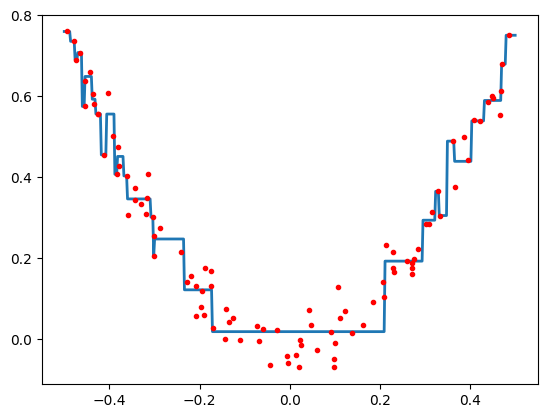

4


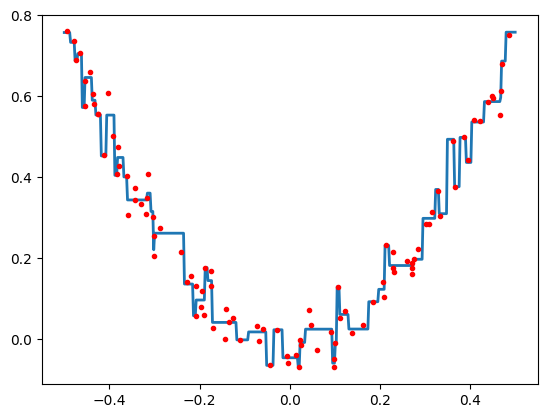

3


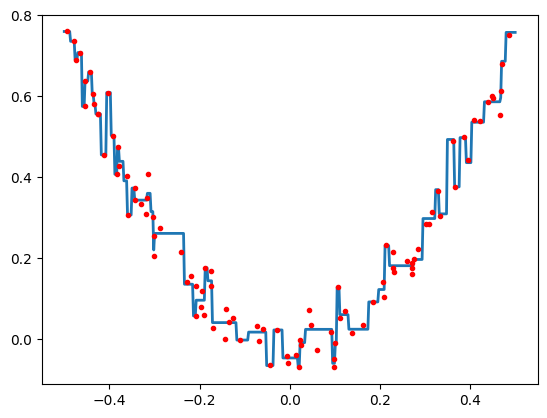

2


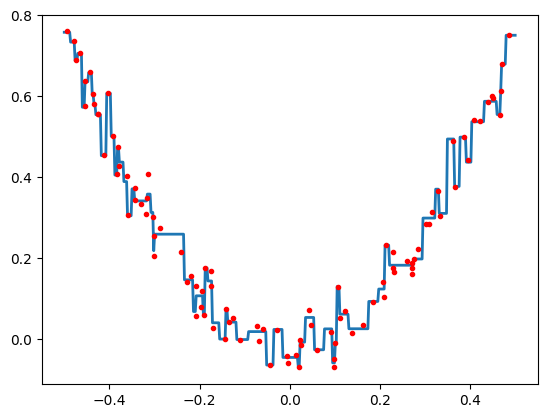

1


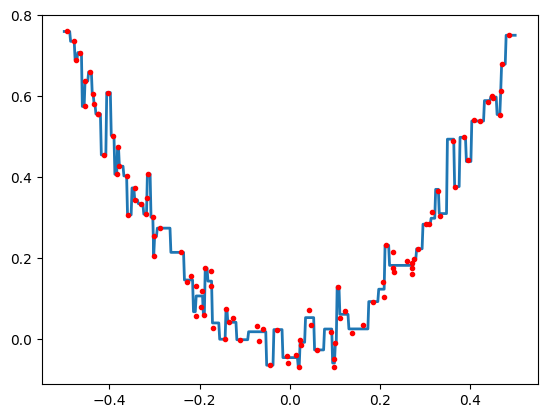

In [34]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)
gradient_boost(X,y,5,lr=1)

# Gradint boosting for classification 

bolg link = https://towardsdatascience.com/all-you-need-to-know-about-gradient-boosting-algorithm-part-2-classification-d3ed8f56541e/

code :- https://colab.research.google.com/drive/15G44KBuSgHs7hdSIuhwh-LR7Qur4xRyD?usp=sharing
code :- https://colab.research.google.com/drive/13p46IFhg3h6BIdjxUcfXPco13jIOCV6I?usp=sharing